In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [131]:
df=pd.read_csv('./data/concrete_data.csv')

In [132]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [134]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [135]:
df.shape

(1030, 9)

<Axes: >

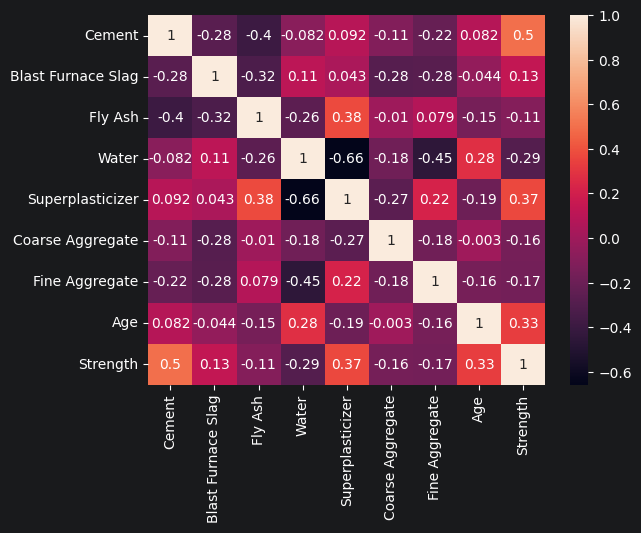

In [136]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

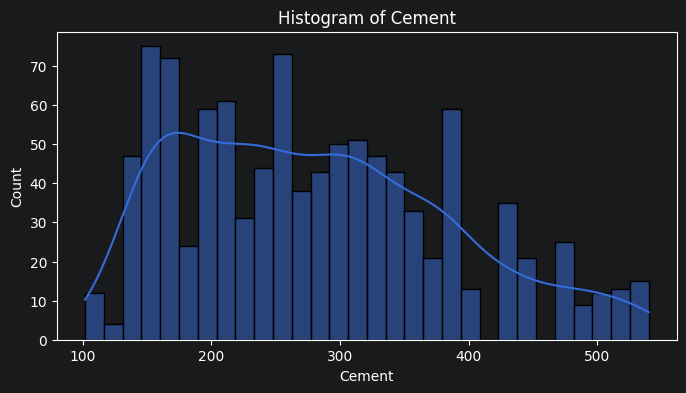

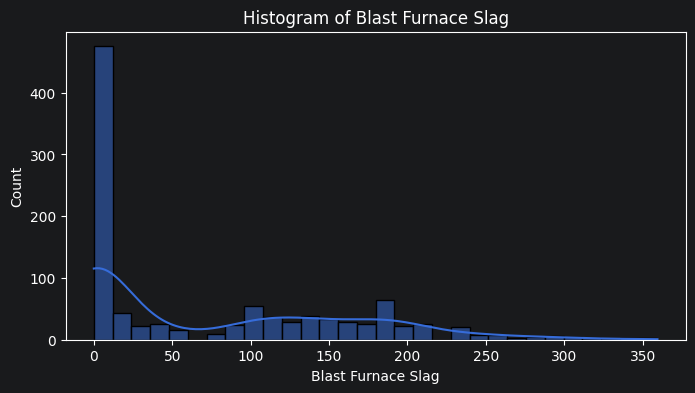

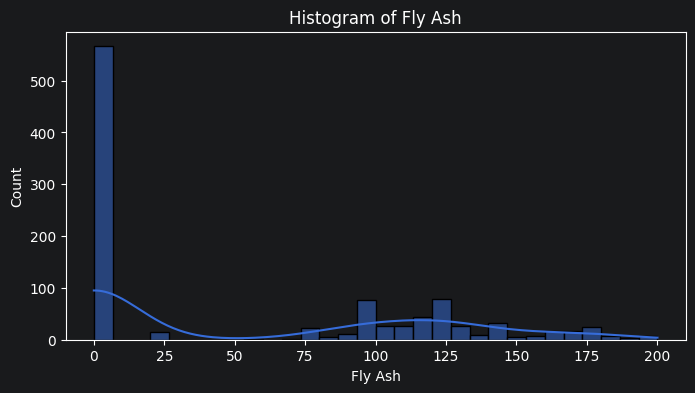

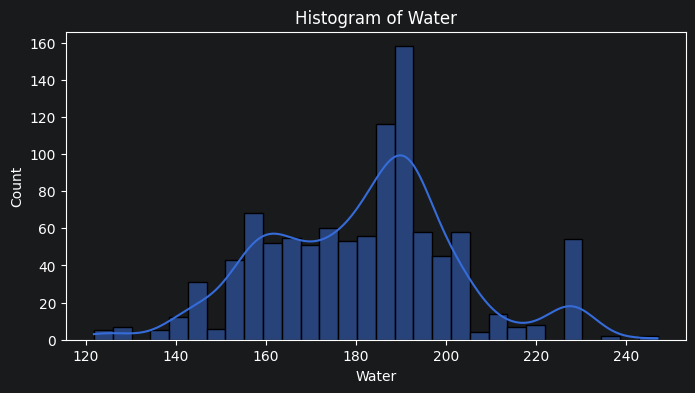

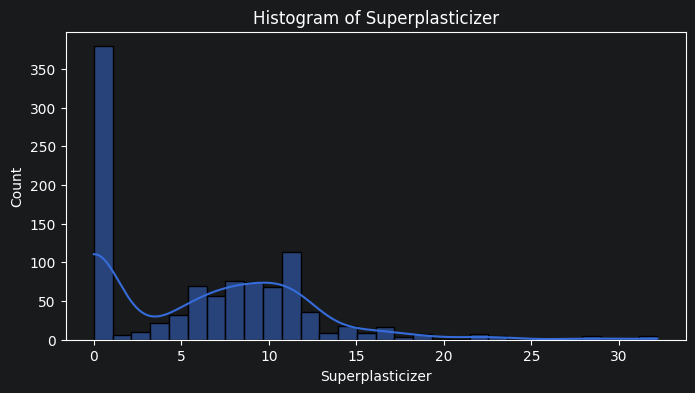

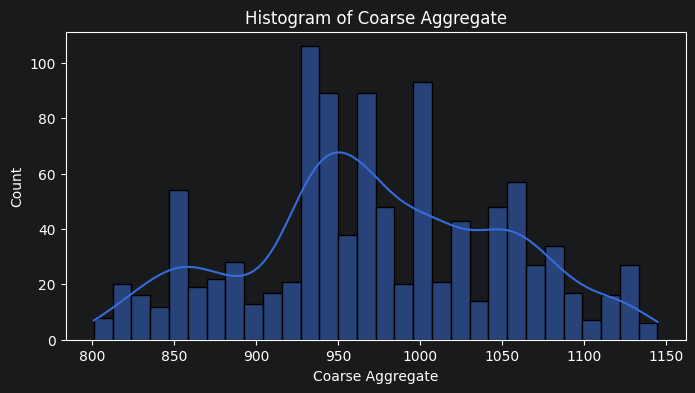

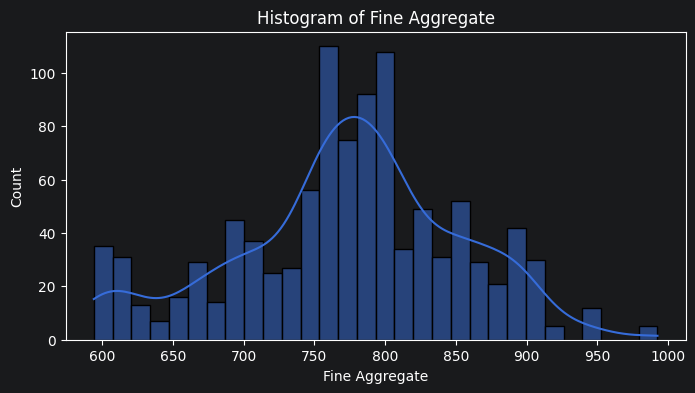

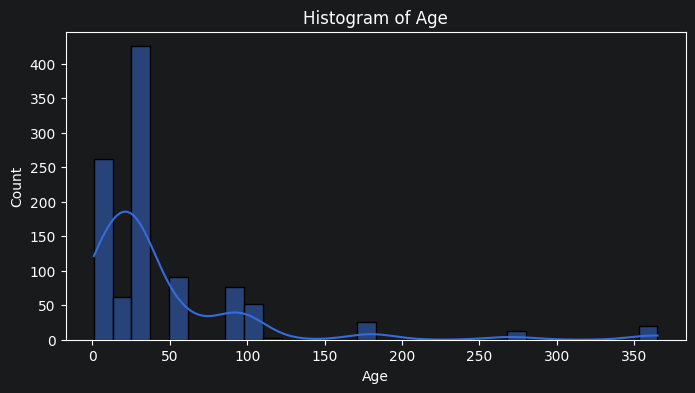

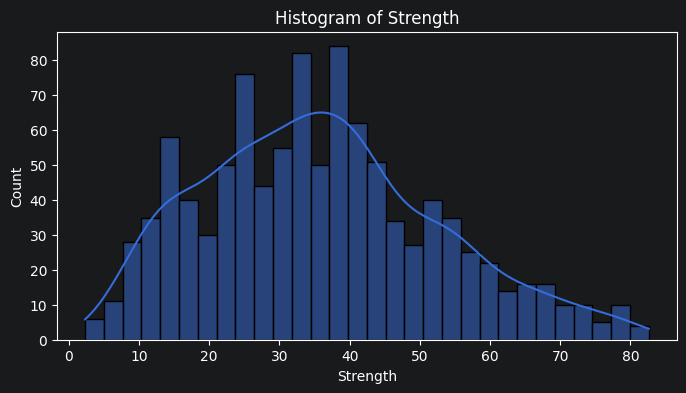

In [137]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

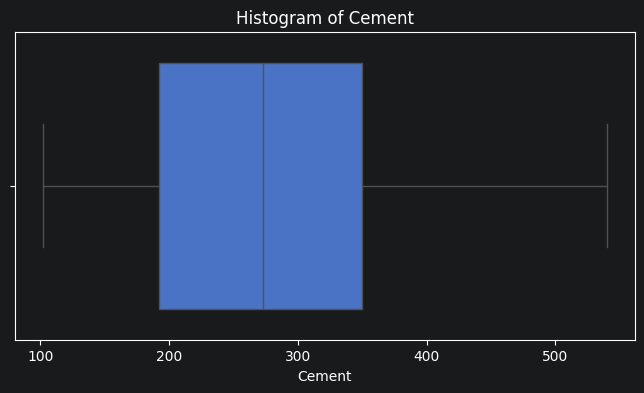

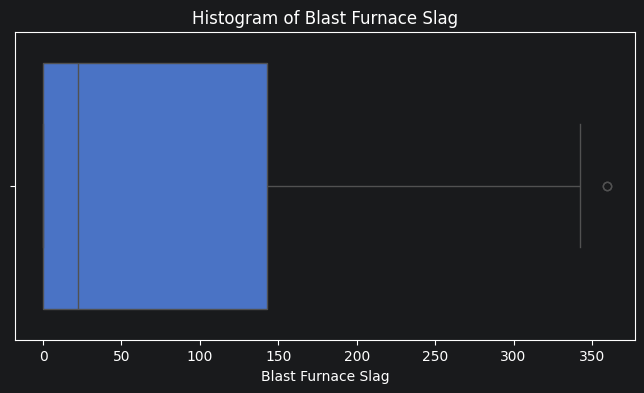

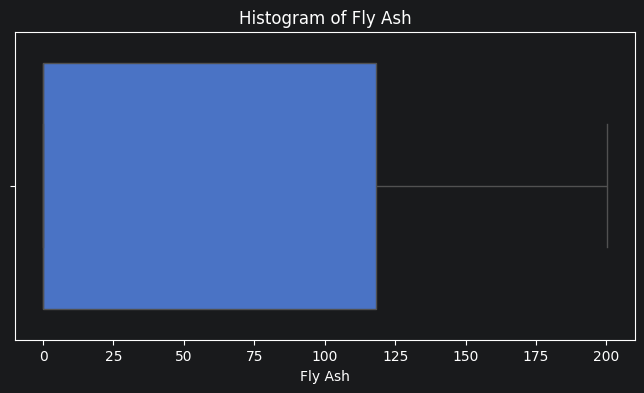

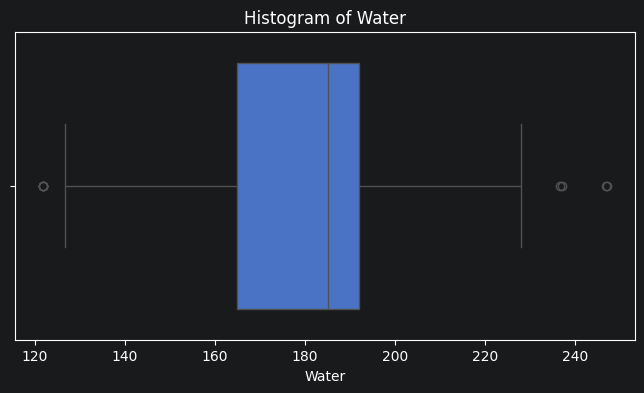

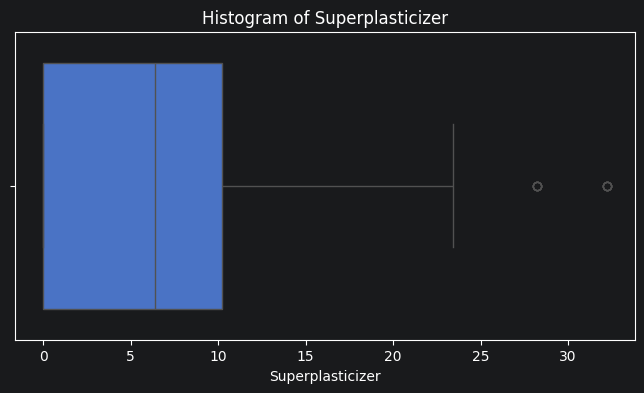

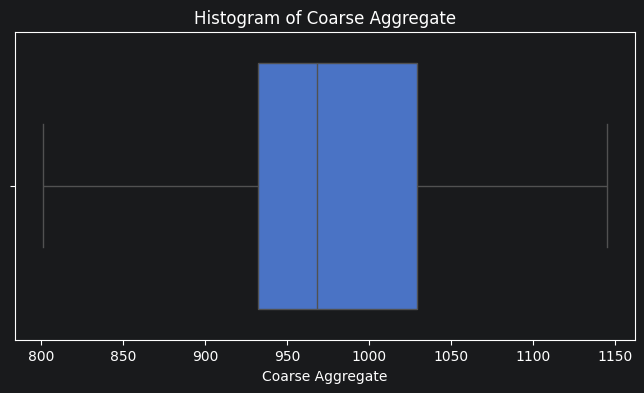

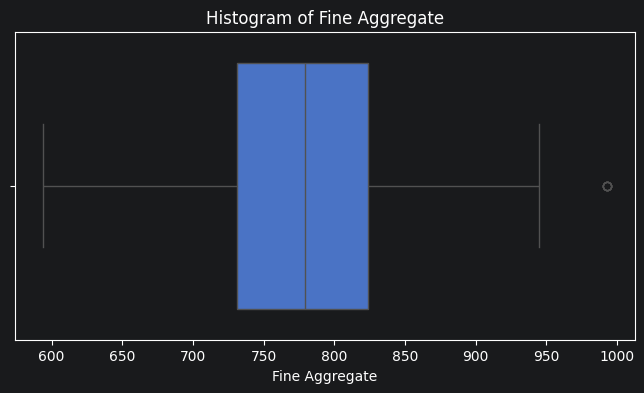

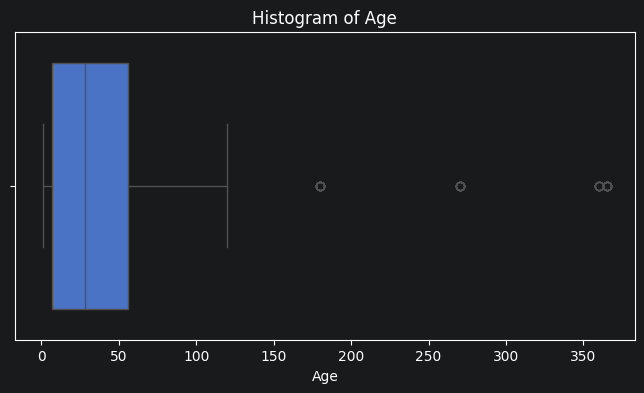

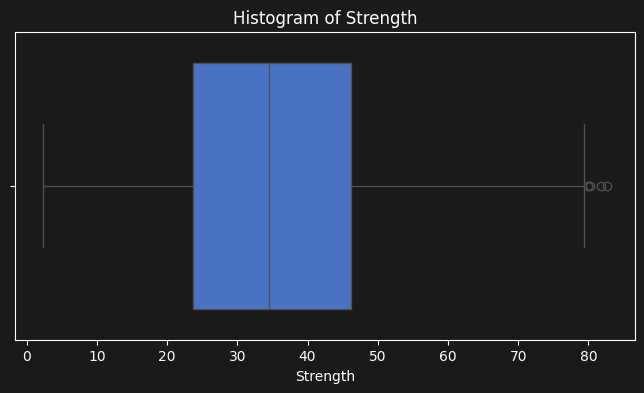

In [138]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Histogram of {col}")
    plt.show()

In [139]:
skewed_cols = df.skew()[abs(df.skew()) > 1].index
for col in skewed_cols:
    if df[col].min() > 0:
        df[col] = np.log1p(df[col])

In [140]:
from sklearn.model_selection import train_test_split,GridSearchCV

x=df.drop(columns=['Strength'])
y=df['Strength']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [141]:
from sklearn.preprocessing import StandardScaler

scale=StandardScaler()

x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

In [142]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error

knn=KNeighborsRegressor(n_neighbors=5)

In [143]:
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)

In [144]:
print("r2_score:",r2_score(y_test,y_pred))
print("mean_squared_error:",mean_squared_error(y_test,y_pred))
print("mean_absolute_error:",mean_absolute_error(y_test,y_pred))
print("root_mean_squared_error:",root_mean_squared_error(y_test,y_pred))

r2_score: 0.8209899718386285
mean_squared_error: 46.126748116504864
mean_absolute_error: 4.87916504854369
root_mean_squared_error: 6.791667550499278


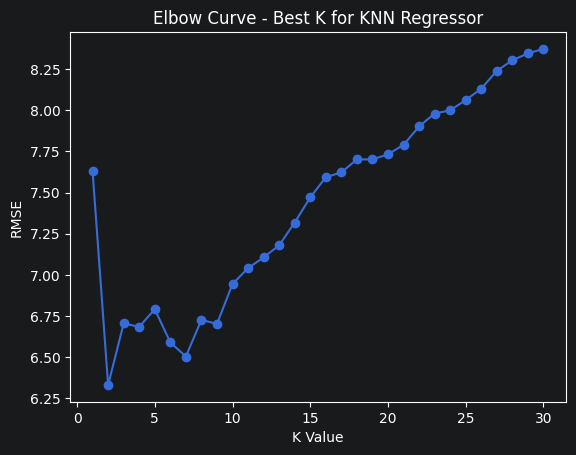

In [145]:
train_rmse = []
test_rmse = []

for k in range(1, 31):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train, y_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, knn.predict(x_train))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, knn.predict(x_test))))

plt.plot(range(1, 31), test_rmse, marker='o')
plt.xlabel('K Value')
plt.ylabel('RMSE')
plt.title('Elbow Curve - Best K for KNN Regressor')
plt.show()

In [146]:
knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

RMSE: 6.684134274624769
R2: 0.8266136701483742


In [147]:
param_grid = {
    'n_neighbors': range(1, 31),
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='r2')
grid.fit(x_train, y_train)

print("Best Params:", grid.best_params_)
print("Best R2:", grid.best_score_)

Best Params: {'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'distance'}
Best R2: 0.8777717307825826


In [148]:
y_pred=grid.predict(x_test)
print("r2_score:",r2_score(y_test,y_pred))
print("mean_squared_error:",mean_squared_error(y_test,y_pred))
print("mean_absolute_error:",mean_absolute_error(y_test,y_pred))
print("root_mean_squared_error:",root_mean_squared_error(y_test,y_pred))

r2_score: 0.8592184405017781
mean_squared_error: 36.276155035120645
mean_absolute_error: 3.824962814298146
root_mean_squared_error: 6.022968955184863


In [149]:
from sklearn.model_selection import cross_val_score

knn = KNeighborsRegressor(n_neighbors=4)

scores = cross_val_score(knn, x_train, y_train, cv=5, scoring='r2')
print("CV R2 Scores:", scores)
print("Mean R2:", np.mean(scores))
print("Std:", np.std(scores))

CV R2 Scores: [0.84388487 0.84229112 0.88006032 0.84485942 0.83622603]
Mean R2: 0.8494643518668212
Std: 0.015589469922638315
